# Storage Benchmark: Database Engines

**Docker image**: `benchmark`

> **Docker required**: This notebook depends on the `benchmark` environment and
> database services. Run with:
> ```bash
> docker compose --profile benchmark up -d timescaledb clickhouse questdb influxdb
> docker compose --profile benchmark run --rm benchmark python 02_financial_data_universe/21_storage_benchmark_database.py
> ```

**Focus**: Query-capable databases for financial time-series

## Database Categories

| Category | Examples | Characteristics |
|----------|----------|-----------------|
| **Embedded** | SQLite, DuckDB, ArcticDB | In-process, no server required |
| **Time-Series Servers** | ClickHouse, QuestDB, TimescaleDB | Production-scale, Docker required |
| **General Purpose** | PostgreSQL, InfluxDB | Baseline comparisons |
| **HFT Specialized** | kdb+/PyKX | Industry standard for trading |

## Operations Benchmarked

1. **Write** - Bulk insert performance
2. **Read** - Full table scan
3. **Range Query** - 7-day time window (backtesting workflow)
4. **OHLCV Aggregation** - Resample minute bars to daily bars
5. **ASOF Join** - Trade-quote alignment (critical for microstructure)

## Timing Policy

One policy, applied identically to every engine. Engines that were timed
under different rules would not belong on the same chart, so the rules are
stated here and enforced by the `time_write` / `time_read` helpers rather
than by per-call arguments:

- **Writes** (`time_write`) - a single shot, no warm-up, against a table
  created fresh for the run. Bulk load happens once per dataset, so that is
  what we time. Repeating it would append duplicate rows on the append-only
  engines, or require a teardown that is not part of the write.
- **Durability inside the timed region.** PostgreSQL and TimescaleDB commit
  synchronously, so their flush cost is inside the timed call. QuestDB (ILP
  + WAL) and InfluxDB acknowledge before the rows are queryable, so they
  poll to first-queryable via `wait_until_rows_visible` *inside* the timed
  call. Every write time therefore ends at the same event: the data is
  durable and readable.
- **Reads, aggregations, and joins** (`time_read`) - mean of `TIMING_RUNS`
  runs after one untimed warm-up. **These are warm numbers**, on both the OS
  page cache and each server's buffer pool, and they flatter every engine
  that caches. A client cannot drop a server's cache, so a "cold" read here
  would be cold for the embedded engines and warm for the servers - neither
  cold nor comparable. Warm and uniform is the measurable choice; §2.4 says
  so where it reports these figures.
- **Every read is validated** against the expected row count. A query that
  silently returns a truncated result would otherwise post the fastest time
  on the chart.

## What the size column does and does not mean

Unlike the timings, on-disk size is **not** measured the same way for every
engine, because each engine only exposes its own accounting. Read the size
column as "what this engine reports it is using", not as a like-for-like
compression ratio:

| Engine | Reported by | Counts |
|--------|-------------|--------|
| SQLite / DuckDB | file size on disk | the database file |
| ClickHouse | `system.parts.bytes_on_disk` | **compressed** data parts |
| QuestDB | `table_storage().diskSize` | the table's full on-disk footprint |
| PostgreSQL / TimescaleDB | `pg_total_relation_size` / `hypertable_size` | table **plus indexes** (and, for the hypertable, all its chunks) |
| InfluxDB | *not exposed* | client API reports no per-bucket size, so it is left empty rather than recorded as zero |

Comparing ClickHouse's compressed parts against PostgreSQL's table-plus-index
total is not a compression comparison. The file-format notebook
(`20_storage_benchmark_file`) is where size is measured identically across
contenders and can be compared directly.

## Quick Start

```bash
# Embedded only (no Docker needed)
BENCHMARK_SCALE=S uv run python storage_benchmark_databases.py

# With server databases (start Docker first)
docker compose --profile benchmark up -d timescaledb clickhouse questdb influxdb
BENCHMARK_SCALE=L uv run python storage_benchmark_databases.py
```

## Setup

In [1]:
"""Storage Benchmark — Database engine comparison for financial time-series."""

import contextlib
import gc
import json
import os
import shutil
import sqlite3
import subprocess
import time as time_module
import urllib.parse
import urllib.request
import warnings
from datetime import UTC, timedelta
from pathlib import Path

In [2]:
# Production scale follows chapter §2.4 prose ("L scale, ~1 M OHLCV rows").
# Override via Papermill for CI: BENCHMARK_SCALE = "S".
BENCHMARK_SCALE = "L"

In [3]:
# storage_benchmarks reads BENCHMARK_SCALE at import time, so the env var must
# be set before the import below.
os.environ["BENCHMARK_SCALE"] = BENCHMARK_SCALE

import pandas as pd
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from utils.paths import get_output_dir
from utils.storage_benchmarks import (
    ACTIVE_SCALE,
    BENCHMARK_DIR,
    DB_CONFIG,
    N_ROWS_PER_SYMBOL,
    N_SYMBOLS,
    N_TICKS_QUOTES,
    N_TICKS_TRADES,
    TIMING_RUNS,
    WAL_FLUSH_TIMEOUT,
    BenchmarkResult,
    estimate_memory_mb,
    force_materialize_pandas,
    force_materialize_polars,
    generate_ohlcv_data,
    generate_tick_data,
    get_scale_config,
    save_benchmark_results,
    save_chart,
    time_read,
    time_write,
    validate_result,
    wait_until_rows_visible,
)
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [4]:
OUTPUT_DIR = get_output_dir(2, "storage_benchmark")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Check Available Databases

In [5]:
# Track benchmark status
benchmark_status = {
    # Embedded (always available if package installed)
    "SQLite": {"expected": True, "tested": False, "category": "embedded"},
    "DuckDB": {"expected": False, "tested": False, "category": "embedded"},
    "ArcticDB": {"expected": False, "tested": False, "category": "embedded"},
    # Servers (need Docker)
    "ClickHouse": {"expected": True, "tested": False, "category": "server"},
    "QuestDB": {"expected": True, "tested": False, "category": "server"},
    "TimescaleDB": {"expected": True, "tested": False, "category": "server"},
    "InfluxDB": {"expected": True, "tested": False, "category": "server"},
    "PostgreSQL": {"expected": True, "tested": False, "category": "server"},
    "kdb+/PyKX": {"expected": False, "tested": False, "category": "hft"},
}

print("=" * 70)
print(f"DATABASE BENCHMARK - Scale: {ACTIVE_SCALE}")
print("=" * 70)

# === Check Embedded Databases ===
# DuckDB ships in both the `benchmark` (ARM64) and `benchmark-full` (x86)
# images. ArcticDB is x86-only — it lives in `benchmark-full`. SQLite is
# always available via stdlib.
try:
    import duckdb  # noqa: F401
except ImportError as exc:
    raise ImportError(
        "DuckDB is not available in the current image.\n"
        "This notebook runs in the `benchmark` image:\n"
        "  docker compose --profile benchmark run --rm benchmark \\\n"
        "      python 02_financial_data_universe/21_storage_benchmark_database.py"
    ) from exc

print("\n### Embedded Databases")
benchmark_status["DuckDB"]["expected"] = True
print("[OK] DuckDB: Available")
print("[OK] SQLite: Available (built-in)")

try:
    import arcticdb as adb

    HAS_ARCTICDB = True
    benchmark_status["ArcticDB"]["expected"] = True
    print("[OK] ArcticDB: Available")
except ImportError:
    HAS_ARCTICDB = False
    print("○ ArcticDB: Not installed (x86-only — use the benchmark-full image)")

DATABASE BENCHMARK - Scale: L

### Embedded Databases
[OK] DuckDB: Available
[OK] SQLite: Available (built-in)
○ ArcticDB: Not installed (x86-only — use the benchmark-full image)


In [6]:
# === Check Server Databases ===
print("\n### Server Databases (Docker required)")

# ClickHouse
try:
    import clickhouse_connect

    ch_client = clickhouse_connect.get_client(
        host=DB_CONFIG["clickhouse"]["host"], port=DB_CONFIG["clickhouse"]["port"]
    )
    ch_client.query("SELECT 1")
    HAS_CLICKHOUSE = True
    print("[OK] ClickHouse: Available")
except Exception:
    HAS_CLICKHOUSE = False
    print("[FAIL] ClickHouse: Not available (start Docker)")

# QuestDB
try:
    urllib.request.urlopen(
        f"http://{DB_CONFIG['questdb']['host']}:{DB_CONFIG['questdb']['http_port']}/exec?query=SELECT%201",
        timeout=2,
    )
    HAS_QUESTDB = True
    print("[OK] QuestDB: Available")
except Exception:
    HAS_QUESTDB = False
    print("[FAIL] QuestDB: Not available (start Docker)")


### Server Databases (Docker required)
[OK] ClickHouse: Available
[OK] QuestDB: Available


In [7]:
# Check TimescaleDB and InfluxDB availability
try:
    import psycopg2

    ts_conn = psycopg2.connect(
        host=DB_CONFIG["timescaledb"]["host"],
        port=DB_CONFIG["timescaledb"]["port"],
        user=DB_CONFIG["timescaledb"]["user"],
        password=DB_CONFIG["timescaledb"]["password"],
        database=DB_CONFIG["timescaledb"]["database"],
        connect_timeout=2,
    )
    ts_conn.close()
    HAS_TIMESCALEDB = True
    print("[OK] TimescaleDB: Available")
except Exception:
    HAS_TIMESCALEDB = False
    print("[FAIL] TimescaleDB: Not available (start Docker)")

# InfluxDB
try:
    from influxdb_client import InfluxDBClient

    influx_test = InfluxDBClient(
        url=f"http://{DB_CONFIG['influxdb']['host']}:{DB_CONFIG['influxdb']['port']}",
        token=DB_CONFIG["influxdb"]["token"],
        org=DB_CONFIG["influxdb"]["org"],
        timeout=2000,
    )
    HAS_INFLUXDB = bool(influx_test.ready())
    influx_test.close()
    if HAS_INFLUXDB:
        print("[OK] InfluxDB: Available")
    else:
        print("[FAIL] InfluxDB: Not ready")
except Exception:
    HAS_INFLUXDB = False
    print("[FAIL] InfluxDB: Not available (start Docker)")

[OK] TimescaleDB: Available


[OK] InfluxDB: Available


In [8]:
# PostgreSQL (vanilla, separate from TimescaleDB)
try:
    import psycopg2

    pg_conn_check = psycopg2.connect(
        host=DB_CONFIG["postgres"]["host"],
        port=DB_CONFIG["postgres"]["port"],
        user=DB_CONFIG["postgres"]["user"],
        password=DB_CONFIG["postgres"]["password"],
        database=DB_CONFIG["postgres"]["database"],
        connect_timeout=2,
    )
    pg_conn_check.close()
    HAS_POSTGRES = True
    print("[OK] PostgreSQL: Available")
except Exception:
    HAS_POSTGRES = False
    print("[FAIL] PostgreSQL: Not available (start Docker)")

[OK] PostgreSQL: Available


In [9]:
# PyKX/kdb+ (IPC mode with external q process)
HAS_PYKX = False
Q_BINARY: Path | None = None

# Check multiple locations for q binary (host install or Docker mount)
Q_BINARY_LOCATIONS = [
    Path.home() / ".kx" / "bin" / "q",  # Standard location
    Path("/opt/kx/bin/q"),  # Alternative system location
]
KX_LICENSE_DIRS = [Path.home() / ".pykx", Path.home() / ".kx"]

# Look for the q binary and a licence BEFORE importing PyKX. The order matters:
# PyKX must never be imported in unlicensed mode (`PYKX_UNLICENSED=1`), which is
# what this cell used to do. Unlicensed PyKX 4.0 leaves the process in a state
# where later numpy work segfaults — the crash lands in `generate_ohlcv_data`,
# nowhere near this cell, so it reads as a data bug rather than an import one.
# Without a licence there is nothing to benchmark anyway, so we simply do not
# import PyKX at all and skip kdb+.
for q_path in Q_BINARY_LOCATIONS:
    if q_path.exists() and q_path.is_file():
        Q_BINARY = q_path
        break

KX_LICENSE_FILE = next(
    (d / f for d in KX_LICENSE_DIRS for f in ("kc.lic", "k4.lic") if (d / f).exists()), None
)

if Q_BINARY is None or KX_LICENSE_FILE is None:
    print("○ PyKX/kdb+: Optional (not configured) — skipping, no result will be claimed")
    if Q_BINARY is None:
        print("    → Get a free personal edition: https://kx.com/kdb-personal-edition-download/")
        print(f"    → Install the q binary to: {Q_BINARY_LOCATIONS[0]}")
    if KX_LICENSE_FILE is None:
        print(f"    → Place the licence file (kc.lic) in: {KX_LICENSE_DIRS[0]}")
else:
    try:
        # q resolves its licence from QLIC, not from the file merely existing on
        # disk: without this the q process starts and dies "no license loaded".
        os.environ["QLIC"] = str(KX_LICENSE_FILE.parent)
        import pykx as kx

        HAS_PYKX = True
        benchmark_status["kdb+/PyKX"]["expected"] = True
        print(f"[OK] PyKX/kdb+ {kx.__version__}: Available (IPC mode, licence {KX_LICENSE_FILE})")
    except ImportError:
        print("○ PyKX/kdb+: Not installed (optional — `uv pip install pykx`)")


Welcome to KDB-X Community Edition!
For Community support, please visit https://kx.com/slack
Tutorials can be found at https://github.com/KxSystems/tutorials
Ready to go beyond the Community Edition? Email preview@kx.com

[OK] PyKX/kdb+ 4.0.0: Available (IPC mode, licence ~/.pykx/kc.lic)


In [10]:
# Availability summary
n_embedded = 2 + int(HAS_ARCTICDB)  # sqlite + duckdb (+ arcticdb if x86)
n_servers = sum([HAS_CLICKHOUSE, HAS_QUESTDB, HAS_TIMESCALEDB, HAS_INFLUXDB, HAS_POSTGRES])
n_hft = int(HAS_PYKX)

print(f"\n[OK] {n_embedded} embedded + {n_servers} server + {n_hft} HFT database(s) available")

if n_servers == 0:
    print("\n[WARN]  No server databases. Start Docker containers:")
    print(
        "   docker compose --profile benchmark up -d timescaledb clickhouse questdb influxdb postgres"
    )


[OK] 2 embedded + 5 server + 1 HFT database(s) available


## Generate Test Data

In [11]:
scale_cfg = get_scale_config(ACTIVE_SCALE)
print(f"\nTarget: {scale_cfg['target_memory']} in-memory")
print(f"OHLCV: {N_SYMBOLS} symbols × {N_ROWS_PER_SYMBOL:,} rows/symbol")
print(f"Tick: {N_TICKS_TRADES:,} trades, {N_TICKS_QUOTES:,} quotes")

print("\n=== Generating synthetic data ===\n")

# Generate OHLCV data
ohlcv_df = generate_ohlcv_data(n_symbols=N_SYMBOLS, n_rows=N_ROWS_PER_SYMBOL)
total_rows = len(ohlcv_df)
memory_mb = estimate_memory_mb(ohlcv_df)
print(f"OHLCV data: {total_rows:,} rows ({memory_mb:.2f} MB)")

# Generate tick data for ASOF joins
trades_df, quotes_df = generate_tick_data(
    n_trades=N_TICKS_TRADES, n_quotes=N_TICKS_QUOTES, n_symbols=N_SYMBOLS
)
print(f"Tick data: {len(trades_df):,} trades, {len(quotes_df):,} quotes")

# pandas versions (some tools require pandas)
ohlcv_pandas = ohlcv_df.to_pandas()
trades_pandas = trades_df.to_pandas()
quotes_pandas = quotes_df.to_pandas()

# Results collection
results: list[BenchmarkResult] = []


Target: 100MB in-memory
OHLCV: 100 symbols × 10,000 rows/symbol
Tick: 500,000 trades, 2,500,000 quotes

=== Generating synthetic data ===



OHLCV data: 1,000,000 rows (63.90 MB)


Tick data: 500,000 trades, 2,500,000 quotes


## Benchmark Windows

Two derived quantities that every engine below reuses, so that all engines
answer the *same* question and can be validated against the same expected
row count:

- **Range query**: the first 7 calendar days of the panel — the slice a
  backtest walks. Against session-aware minute bars this covers 5 trading
  sessions, a real fraction of the panel rather than a full scan.
- **Aggregation**: minute bars resampled to **daily** bars. Every engine
  buckets by day; bucketing minute data by minute would be a near-identity
  for the engines that did it and a real reduction for the ones that didn't,
  which is not a comparison.

In [12]:
RANGE_QUERY_DAYS = 7

range_start = ohlcv_df["timestamp"].min()
range_end = range_start + timedelta(days=RANGE_QUERY_DAYS)
range_expected_rows = ohlcv_df.filter(
    (pl.col("timestamp") >= range_start) & (pl.col("timestamp") < range_end)
).height
agg_expected_rows = ohlcv_df.select(
    pl.struct("symbol", pl.col("timestamp").dt.truncate("1d")).n_unique()
).item()

n_sessions = ohlcv_df.select(pl.col("timestamp").dt.date().n_unique()).item()
print(f"Panel spans {n_sessions} trading sessions: {range_start} → {ohlcv_df['timestamp'].max()}")
print(
    f"Range query  : {range_start} ≤ timestamp < {range_end} "
    f"→ {range_expected_rows:,} rows ({range_expected_rows / total_rows:.1%} of panel)"
)
print(f"Aggregation  : minute bars → {agg_expected_rows:,} daily bars")

Panel spans 26 trading sessions: 2024-01-02 09:30:00 → 2024-02-06 13:39:00
Range query  : 2024-01-02 09:30:00 ≤ timestamp < 2024-01-09 09:30:00 → 195,000 rows (19.5% of panel)
Aggregation  : minute bars → 2,600 daily bars


---
# Part 1: Embedded Databases
---

## SQLite (Embedded RDBMS)

SQLite is an embedded relational database:
- ACID compliant, single-file database
- Good for transactional workloads (OLTP)
- Limited analytical query optimization
- No native ASOF join

In [13]:
print("\n" + "=" * 70)
print("SQLITE BENCHMARK")
print("=" * 70)

benchmark_status["SQLite"]["tested"] = True
sqlite_path = BENCHMARK_DIR / f"ohlcv_{ACTIVE_SCALE.lower()}.db"


# Write
def write_sqlite():
    if sqlite_path.exists():
        sqlite_path.unlink()
    with contextlib.closing(sqlite3.connect(sqlite_path)) as conn:
        ohlcv_pandas.to_sql("ohlcv", conn, if_exists="replace", index=False)
        conn.execute("CREATE INDEX IF NOT EXISTS idx_symbol_timestamp ON ohlcv(symbol, timestamp)")


write_time, _ = time_write(write_sqlite)
sqlite_size = sqlite_path.stat().st_size
results.append(BenchmarkResult("SQLite", "write", write_time, sqlite_size, total_rows))


SQLITE BENCHMARK


### SQLite Read and Aggregation

In [14]:
def read_sqlite():
    with contextlib.closing(sqlite3.connect(sqlite_path)) as conn:
        df = pd.read_sql("SELECT * FROM ohlcv", conn)
    return force_materialize_pandas(df)


read_time, sqlite_result = time_read(read_sqlite)
validate_result(sqlite_result, total_rows, "SQLite read")
results.append(BenchmarkResult("SQLite", "read", read_time, sqlite_size, total_rows))

### SQLite Range Query

SQLite stores the timestamps as ISO-8601 text, which sorts lexicographically,
so the string bounds below use the covering `(symbol, timestamp)` index.

In [15]:
SQLITE_TS_FMT = "%Y-%m-%d %H:%M:%S"


def sqlite_range_query():
    with contextlib.closing(sqlite3.connect(sqlite_path)) as conn:
        df = pd.read_sql(
            "SELECT * FROM ohlcv WHERE timestamp >= ? AND timestamp < ?",
            conn,
            params=(range_start.strftime(SQLITE_TS_FMT), range_end.strftime(SQLITE_TS_FMT)),
        )
    return force_materialize_pandas(df)


range_time, sqlite_range = time_read(sqlite_range_query)
validate_result(sqlite_range, range_expected_rows, "SQLite range query")
results.append(BenchmarkResult("SQLite", "range_query", range_time, 0, len(sqlite_range)))

### SQLite OHLCV Aggregation

`open` is the first price of the session and `close` the last, ordered by
time — not `MIN(open)` / `MAX(close)`, which are a different (and wrong)
statistic. SQLite has no `first`/`last` aggregate, so the OHLCV reduction
needs window functions. That costs SQLite time relative to the engines with
native `first`/`last`, and that cost is the honest answer to "what does this
aggregation take on SQLite?"

In [16]:
def sqlite_aggregation():
    with contextlib.closing(sqlite3.connect(sqlite_path)) as conn:
        query = """
            SELECT DISTINCT symbol, date(timestamp) as bar_date,
                   FIRST_VALUE(open) OVER w as open,
                   MAX(high) OVER w as high,
                   MIN(low) OVER w as low,
                   LAST_VALUE(close) OVER w as close,
                   SUM(volume) OVER w as volume
            FROM ohlcv
            WINDOW w AS (
                PARTITION BY symbol, date(timestamp) ORDER BY timestamp
                ROWS BETWEEN UNBOUNDED PRECEDING AND UNBOUNDED FOLLOWING
            )
        """
        return pd.read_sql(query, conn)


agg_time, agg_result = time_read(sqlite_aggregation)
validate_result(agg_result, agg_expected_rows, "SQLite aggregation")
results.append(BenchmarkResult("SQLite", "aggregation", agg_time, 0, len(agg_result)))

print(f"\nSQLite: {sqlite_size / 1e6:.1f} MB")
print(f"  Write: {write_time:.3f}s ({total_rows / write_time / 1e6:.2f}M rows/s)")
print(f"  Read:  {read_time:.3f}s ({total_rows / read_time / 1e6:.2f}M rows/s)")
print(f"  Range query: {range_time:.3f}s ({len(sqlite_range):,} rows)")
print(f"  Aggregation: {agg_time:.3f}s ({len(agg_result):,} daily bars)")
print("  Note: No native ASOF join")


SQLite: 123.3 MB
  Write: 2.511s (0.40M rows/s)
  Read:  2.040s (0.49M rows/s)
  Range query: 0.479s (195,000 rows)
  Aggregation: 1.204s (2,600 daily bars)
  Note: No native ASOF join


## DuckDB (Embedded Analytics)

DuckDB is designed for analytical workloads (OLAP):
- Columnar storage, vectorized execution
- Native ASOF join support (v1.1+)
- Zero-copy reads from Parquet
- Out-of-core processing for data larger than RAM

In [17]:
print("\n" + "=" * 70)
print("DUCKDB BENCHMARK")
print("=" * 70)

benchmark_status["DuckDB"]["tested"] = True
duckdb_path = BENCHMARK_DIR / f"ohlcv_{ACTIVE_SCALE.lower()}.duckdb"
parquet_path = BENCHMARK_DIR / f"ohlcv_{ACTIVE_SCALE.lower()}.parquet"

# Save to Parquet for DuckDB's preferred workflow
ohlcv_df.write_parquet(parquet_path)


# Write DuckDB native
def write_duckdb():
    if duckdb_path.exists():
        duckdb_path.unlink()
    conn = duckdb.connect(str(duckdb_path))
    conn.execute("CREATE TABLE ohlcv AS SELECT * FROM read_parquet(?)", [str(parquet_path)])
    conn.close()


write_time, _ = time_write(write_duckdb)
duckdb_size = duckdb_path.stat().st_size
results.append(BenchmarkResult("DuckDB", "write", write_time, duckdb_size, total_rows))


# Read
def read_duckdb():
    conn = duckdb.connect(str(duckdb_path), read_only=True)
    df = conn.execute("SELECT * FROM ohlcv").pl()
    conn.close()
    return force_materialize_polars(df)


read_time, duckdb_result = time_read(read_duckdb)
validate_result(duckdb_result, total_rows, "DuckDB read")
results.append(BenchmarkResult("DuckDB", "read", read_time, duckdb_size, total_rows))


DUCKDB BENCHMARK


In [18]:
# Range query
def duckdb_range_query():
    conn = duckdb.connect(str(duckdb_path), read_only=True)
    df = conn.execute(
        "SELECT * FROM ohlcv WHERE timestamp >= ? AND timestamp < ?", [range_start, range_end]
    ).pl()
    conn.close()
    return force_materialize_polars(df)


range_time, duckdb_range = time_read(duckdb_range_query)
validate_result(duckdb_range, range_expected_rows, "DuckDB range query")
results.append(BenchmarkResult("DuckDB", "range_query", range_time, 0, len(duckdb_range)))

In [19]:
# Aggregation
def duckdb_aggregation():
    conn = duckdb.connect(str(duckdb_path), read_only=True)
    result = conn.execute("""
        SELECT symbol, date_trunc('day', timestamp) as bar_date,
               FIRST(open ORDER BY timestamp) as open, MAX(high) as high,
               MIN(low) as low, LAST(close ORDER BY timestamp) as close,
               SUM(volume) as volume
        FROM ohlcv GROUP BY symbol, bar_date ORDER BY symbol, bar_date
    """).pl()
    conn.close()
    return result


agg_time, agg_result = time_read(duckdb_aggregation)
validate_result(agg_result, agg_expected_rows, "DuckDB aggregation")
results.append(BenchmarkResult("DuckDB", "aggregation", agg_time, 0, len(agg_result)))

# ASOF Join
trades_path = BENCHMARK_DIR / f"trades_{ACTIVE_SCALE.lower()}.parquet"
quotes_path = BENCHMARK_DIR / f"quotes_{ACTIVE_SCALE.lower()}.parquet"
trades_df.sort(["symbol", "timestamp"]).write_parquet(trades_path)
quotes_df.sort(["symbol", "timestamp"]).write_parquet(quotes_path)


def duckdb_asof():
    conn = duckdb.connect()
    result = conn.execute(f"""
        SELECT t.*, q.bid, q.ask, q.bid_size, q.ask_size
        FROM read_parquet('{trades_path}') t
        ASOF LEFT JOIN read_parquet('{quotes_path}') q
          ON t.symbol = q.symbol AND t.timestamp >= q.timestamp
    """).pl()
    conn.close()
    return result


asof_time, asof_result = time_read(duckdb_asof)
validate_result(asof_result, N_TICKS_TRADES, "DuckDB ASOF join")
results.append(BenchmarkResult("DuckDB", "asof_join", asof_time, 0, len(asof_result)))

print(f"\nDuckDB: {duckdb_size / 1e6:.1f} MB")
print(f"  Write: {write_time:.3f}s ({total_rows / write_time / 1e6:.2f}M rows/s)")
print(f"  Read:  {read_time:.3f}s ({total_rows / read_time / 1e6:.2f}M rows/s)")
print(f"  Range query: {range_time:.3f}s ({len(duckdb_range):,} rows)")
print(f"  Aggregation: {agg_time:.3f}s ({len(agg_result):,} daily bars)")
print(f"  ASOF Join: {asof_time:.3f}s ({N_TICKS_TRADES / asof_time / 1e6:.2f}M trades/s)")


DuckDB: 45.6 MB
  Write: 0.132s (7.55M rows/s)
  Read:  0.070s (14.34M rows/s)
  Range query: 0.039s (195,000 rows)
  Aggregation: 0.031s (2,600 daily bars)
  ASOF Join: 0.263s (1.90M trades/s)


## ArcticDB (Versioned DataFrames)

ArcticDB is designed for versioned time-series storage:
- "Git for DataFrames" - version history, time travel
- Optimized for financial time-series
- LMDB backend (local), S3/Azure (cloud)

In [20]:
if HAS_ARCTICDB:
    print("\n" + "=" * 70)
    print("ARCTICDB BENCHMARK")
    print("=" * 70)

    benchmark_status["ArcticDB"]["tested"] = True
    arctic_path = BENCHMARK_DIR / f"arctic_{ACTIVE_SCALE.lower()}"

    if arctic_path.exists():
        shutil.rmtree(arctic_path)

    ac = adb.Arctic(f"lmdb://{arctic_path}")
    lib = ac.get_library("benchmark", create_if_missing=True)

    def write_arctic():
        lib.write("ohlcv", ohlcv_pandas, prune_previous_versions=True)

    write_time, _ = time_write(write_arctic)
    arctic_size = sum(f.stat().st_size for f in arctic_path.rglob("*") if f.is_file())
    results.append(BenchmarkResult("ArcticDB", "write", write_time, arctic_size, total_rows))

    def read_arctic():
        df = lib.read("ohlcv").data
        return force_materialize_pandas(df)

    read_time, arctic_result = time_read(read_arctic, n_runs=min(2, TIMING_RUNS))
    validate_result(arctic_result, total_rows, "ArcticDB read")
    results.append(BenchmarkResult("ArcticDB", "read", read_time, arctic_size, total_rows))

    # No range_query for ArcticDB: its server-side `date_range` filter keys off a
    # datetime *index*, and this panel carries `timestamp` as a column (the
    # canonical schema). Pushing the filter down would need a different write
    # layout than the one benchmarked above, so ArcticDB is absent from the
    # range-query chart rather than being timed on a client-side filter that no
    # other engine pays.

    def arctic_aggregation():
        df = lib.read("ohlcv").data
        return (
            df.groupby(["symbol", pd.Grouper(key="timestamp", freq="D")])
            .agg(
                open=("open", "first"),
                high=("high", "max"),
                low=("low", "min"),
                close=("close", "last"),
                volume=("volume", "sum"),
            )
            .reset_index()
        )

    agg_time, agg_result = time_read(arctic_aggregation, n_runs=min(2, TIMING_RUNS))
    results.append(BenchmarkResult("ArcticDB", "aggregation", agg_time, 0, len(agg_result)))

    print(f"\nArcticDB: {arctic_size / 1e6:.1f} MB")
    print(f"  Write: {write_time:.3f}s ({total_rows / write_time / 1e6:.2f}M rows/s)")
    print(f"  Read:  {read_time:.3f}s ({total_rows / read_time / 1e6:.2f}M rows/s)")
    print(f"  Aggregation: {agg_time:.3f}s ({len(agg_result):,} daily bars)")
    print("  Note: Versioning enabled (time travel supported)")

    shutil.rmtree(arctic_path)
else:
    print("\nArcticDB benchmark skipped — install via the benchmark-full image (x86 only).")


ArcticDB benchmark skipped — install via the benchmark-full image (x86 only).


---
# Part 2: Server Databases (Docker Required)
---

## ClickHouse (OLAP Analytics)

ClickHouse excels at:
- Massive aggregations (billions of rows/second)
- Columnar compression (10-15x)
- Native ASOF JOIN

In [21]:
if HAS_CLICKHOUSE:
    print("\n" + "=" * 70)
    print("CLICKHOUSE BENCHMARK")
    print("=" * 70)

    benchmark_status["ClickHouse"]["tested"] = True

    ch_client.command("DROP TABLE IF EXISTS ohlcv_benchmark")
    ch_client.command("""
        CREATE TABLE ohlcv_benchmark (
            timestamp DateTime64(3), symbol String,
            open Float64, high Float64, low Float64, close Float64,
            volume Int64, vwap Float64, num_trades Int32
        ) ENGINE = MergeTree()
        PARTITION BY toYYYYMM(timestamp) ORDER BY (symbol, timestamp)
    """)

    # Write
    def write_clickhouse():
        ch_client.insert_df("ohlcv_benchmark", ohlcv_pandas)

    ch_write_time, _ = time_write(write_clickhouse)
    ch_size = (
        ch_client.query(
            "SELECT sum(bytes_on_disk) FROM system.parts WHERE table = 'ohlcv_benchmark'"
        ).result_set[0][0]
        or 0
    )
    results.append(BenchmarkResult("ClickHouse", "write", ch_write_time, ch_size, total_rows))

    # Read
    def read_clickhouse():
        return ch_client.query_df("SELECT * FROM ohlcv_benchmark")

    ch_read_time, ch_result = time_read(read_clickhouse, n_runs=min(3, TIMING_RUNS))
    validate_result(ch_result, total_rows, "ClickHouse read")
    results.append(BenchmarkResult("ClickHouse", "read", ch_read_time, ch_size, total_rows))


CLICKHOUSE BENCHMARK


In [22]:
if HAS_CLICKHOUSE:
    # Range query
    def clickhouse_range_query():
        return ch_client.query_df(
            "SELECT * FROM ohlcv_benchmark WHERE timestamp >= %(start)s AND timestamp < %(end)s",
            parameters={"start": range_start, "end": range_end},
        )

    ch_range_time, ch_range_result = time_read(clickhouse_range_query, n_runs=min(3, TIMING_RUNS))
    validate_result(ch_range_result, range_expected_rows, "ClickHouse range query")
    results.append(
        BenchmarkResult("ClickHouse", "range_query", ch_range_time, 0, len(ch_range_result))
    )

In [23]:
if HAS_CLICKHOUSE:
    # Aggregation — bucket to DAY, matching every other engine.
    def clickhouse_ohlcv():
        return ch_client.query_df("""
            SELECT symbol, toStartOfDay(timestamp) as bar_time,
                   argMin(open, timestamp) as open, max(high) as high,
                   min(low) as low, argMax(close, timestamp) as close,
                   sum(volume) as volume
            FROM ohlcv_benchmark GROUP BY symbol, bar_time ORDER BY symbol, bar_time
        """)

    ch_agg_time, ch_agg_result = time_read(clickhouse_ohlcv, n_runs=min(3, TIMING_RUNS))
    validate_result(ch_agg_result, agg_expected_rows, "ClickHouse aggregation")
    results.append(BenchmarkResult("ClickHouse", "aggregation", ch_agg_time, 0, len(ch_agg_result)))

In [24]:
if HAS_CLICKHOUSE:
    # ASOF JOIN
    ch_client.command("DROP TABLE IF EXISTS ch_trades")
    ch_client.command("DROP TABLE IF EXISTS ch_quotes")
    ch_client.command("""
        CREATE TABLE ch_trades (timestamp DateTime64(9), symbol String, price Float64, size Int64)
        ENGINE = MergeTree() ORDER BY (symbol, timestamp)
    """)
    ch_client.command("""
        CREATE TABLE ch_quotes (timestamp DateTime64(9), symbol String, bid Float64, ask Float64, bid_size Int64, ask_size Int64)
        ENGINE = MergeTree() ORDER BY (symbol, timestamp)
    """)

    trades_sorted_pd = (
        trades_df.sort(["symbol", "timestamp"])
        .select(["timestamp", "symbol", "price", "size"])
        .to_pandas()
    )
    quotes_sorted_pd = (
        quotes_df.sort(["symbol", "timestamp"])
        .select(["timestamp", "symbol", "bid", "ask", "bid_size", "ask_size"])
        .to_pandas()
    )
    ch_client.insert_df("ch_trades", trades_sorted_pd)
    ch_client.insert_df("ch_quotes", quotes_sorted_pd)

In [25]:
if HAS_CLICKHOUSE:

    def clickhouse_asof():
        return ch_client.query_df("""
            SELECT t.timestamp, t.symbol, t.price, t.size, q.bid, q.ask
            FROM ch_trades t ASOF LEFT JOIN ch_quotes q
            ON t.symbol = q.symbol AND t.timestamp >= q.timestamp
        """)

    ch_asof_time, ch_asof_result = time_read(clickhouse_asof, n_runs=min(3, TIMING_RUNS))
    validate_result(ch_asof_result, N_TICKS_TRADES, "ClickHouse ASOF join")
    results.append(BenchmarkResult("ClickHouse", "asof_join", ch_asof_time, 0, len(ch_asof_result)))

    print(f"\nClickHouse: {ch_size / 1e6:.1f} MB")
    print(f"  Write: {ch_write_time:.3f}s | Read: {ch_read_time:.3f}s")
    print(f"  Range query: {ch_range_time:.3f}s ({len(ch_range_result):,} rows)")
    print(f"  Aggregation: {ch_agg_time:.3f}s ({len(ch_agg_result):,} daily bars)")
    print(f"  ASOF Join: {ch_asof_time:.3f}s ({len(ch_asof_result):,} rows)")

    ch_client.command("DROP TABLE IF EXISTS ohlcv_benchmark")
    ch_client.command("DROP TABLE IF EXISTS ch_trades")
    ch_client.command("DROP TABLE IF EXISTS ch_quotes")
else:
    print("\n⊘ ClickHouse benchmark skipped")


ClickHouse: 52.5 MB
  Write: 0.341s | Read: 0.319s
  Range query: 0.101s (195,000 rows)
  Aggregation: 0.022s (2,600 daily bars)
  ASOF Join: 0.272s (500,000 rows)


## QuestDB (High-Throughput Time-Series)

QuestDB is optimized for:
- Ultra-high ingestion (1M+ rows/second via ILP)
- Time-series specific SQL extensions (SAMPLE BY)
- Native ASOF JOIN

In [26]:
if HAS_QUESTDB:
    print("\n" + "=" * 70)
    print("QUESTDB BENCHMARK")
    print("=" * 70)

    benchmark_status["QuestDB"]["tested"] = True
    from questdb.ingress import Sender

    def questdb_query(sql, limit: str | None = None):
        """Run SQL over QuestDB's HTTP endpoint.

        `/exec` caps the JSON result set unless an explicit `limit` is given, so
        every full-result query below passes one. Without it the endpoint
        returns a truncated page: a fast time on a wrong answer.
        """
        url = (
            f"http://{DB_CONFIG['questdb']['host']}:{DB_CONFIG['questdb']['http_port']}"
            f"/exec?query={urllib.parse.quote(sql)}"
        )
        if limit is not None:
            url += f"&limit={limit}"
        response = urllib.request.urlopen(url, timeout=600)
        return json.loads(response.read())

    def questdb_row_count() -> int:
        try:
            payload = questdb_query("SELECT count() FROM ohlcv_benchmark")
        except Exception:
            return 0  # table not created yet
        dataset = payload.get("dataset") or [[0]]
        return int(dataset[0][0])

    with contextlib.suppress(Exception):
        questdb_query("DROP TABLE IF EXISTS ohlcv_benchmark")

    questdb_query("""
        CREATE TABLE IF NOT EXISTS ohlcv_benchmark (
            timestamp TIMESTAMP, symbol SYMBOL,
            open DOUBLE, high DOUBLE, low DOUBLE, close DOUBLE,
            volume LONG, vwap DOUBLE, num_trades INT
        ) timestamp(timestamp) PARTITION BY DAY WAL
    """)

    # Write via ILP. The WAL commit is polled INSIDE the timed region so that
    # QuestDB's write time ends where PostgreSQL's does: when the rows are
    # queryable. The previous fixed sleep sat outside the timed call, which
    # charged QuestDB nothing for durability.
    def write_questdb():
        with Sender.from_conf(
            f"http::addr={DB_CONFIG['questdb']['host']}:{DB_CONFIG['questdb']['http_port']};"
        ) as sender:
            df_insert = ohlcv_pandas.copy()
            df_insert["timestamp"] = pd.to_datetime(df_insert["timestamp"])
            sender.dataframe(
                df_insert, table_name="ohlcv_benchmark", symbols=["symbol"], at="timestamp"
            )
        return wait_until_rows_visible(
            questdb_row_count, total_rows, timeout=max(60.0, WAL_FLUSH_TIMEOUT * 20)
        )

    qdb_write_time, qdb_visible = time_write(write_questdb)
    assert qdb_visible == total_rows, f"QuestDB ingested {qdb_visible:,} of {total_rows:,}"
    qdb_size = int(
        questdb_query(
            "SELECT sum(diskSize) FROM table_storage() WHERE tableName = 'ohlcv_benchmark'"
        )["dataset"][0][0]
        or 0
    )
    results.append(BenchmarkResult("QuestDB", "write", qdb_write_time, qdb_size, total_rows))


QUESTDB BENCHMARK


In [27]:
if HAS_QUESTDB:
    # Read — explicit limit so the endpoint returns the whole table, then
    # validated like every other engine's read.
    def read_questdb():
        return questdb_query("SELECT * FROM ohlcv_benchmark", limit=f"1,{total_rows}")

    qdb_read_time, qdb_result = time_read(read_questdb, n_runs=min(3, TIMING_RUNS))
    validate_result(qdb_result, total_rows, "QuestDB read")
    results.append(BenchmarkResult("QuestDB", "read", qdb_read_time, qdb_size, total_rows))

    # Range query
    def questdb_range_query():
        sql = (
            "SELECT * FROM ohlcv_benchmark "
            f"WHERE timestamp >= '{range_start.isoformat()}' "
            f"AND timestamp < '{range_end.isoformat()}'"
        )
        return questdb_query(sql, limit=f"1,{range_expected_rows}")

    qdb_range_time, qdb_range_result = time_read(questdb_range_query, n_runs=min(3, TIMING_RUNS))
    validate_result(qdb_range_result, range_expected_rows, "QuestDB range query")
    results.append(
        BenchmarkResult(
            "QuestDB", "range_query", qdb_range_time, 0, len(qdb_range_result["dataset"])
        )
    )

    # OHLCV aggregation (SAMPLE BY) — daily buckets, matching every other engine
    def questdb_ohlcv():
        return questdb_query(
            """
            SELECT symbol, timestamp as bar_time,
                   first(open) as open, max(high) as high, min(low) as low,
                   last(close) as close, sum(volume) as volume
            FROM ohlcv_benchmark SAMPLE BY 1d ALIGN TO CALENDAR
            """,
            limit=f"1,{agg_expected_rows}",
        )

    qdb_agg_time, qdb_agg_result = time_read(questdb_ohlcv, n_runs=min(3, TIMING_RUNS))
    validate_result(qdb_agg_result, agg_expected_rows, "QuestDB aggregation")
    qdb_agg_rows = len(qdb_agg_result["dataset"])
    results.append(BenchmarkResult("QuestDB", "aggregation", qdb_agg_time, 0, qdb_agg_rows))

    print(f"\nQuestDB: {qdb_size / 1e6:.1f} MB")
    print(f"  Write (ILP, to queryable): {qdb_write_time:.3f}s | Read: {qdb_read_time:.3f}s")
    print(f"  Range query: {qdb_range_time:.3f}s ({len(qdb_range_result['dataset']):,} rows)")
    print(f"  OHLCV aggregation: {qdb_agg_time:.3f}s ({qdb_agg_rows:,} daily bars)")

    with contextlib.suppress(Exception):
        questdb_query("DROP TABLE IF EXISTS ohlcv_benchmark")
else:
    print("\n⊘ QuestDB benchmark skipped")


QuestDB: 306.2 MB
  Write (ILP, to queryable): 0.922s | Read: 2.591s
  Range query: 0.518s (195,000 rows)
  OHLCV aggregation: 0.026s (2,600 daily bars)


## TimescaleDB (PostgreSQL + Time-Series)

TimescaleDB combines PostgreSQL with time-series optimizations:
- Hypertables (automatic partitioning)
- time_bucket() for aggregations
- Full SQL + relational integrity

In [28]:
if HAS_TIMESCALEDB:
    print("\n" + "=" * 70)
    print("TIMESCALEDB BENCHMARK")
    print("=" * 70)

    benchmark_status["TimescaleDB"]["tested"] = True
    from psycopg2.extras import execute_values

    conn = psycopg2.connect(
        host=DB_CONFIG["timescaledb"]["host"],
        port=DB_CONFIG["timescaledb"]["port"],
        user=DB_CONFIG["timescaledb"]["user"],
        password=DB_CONFIG["timescaledb"]["password"],
        database=DB_CONFIG["timescaledb"]["database"],
    )
    conn.autocommit = True
    cur = conn.cursor()

    cur.execute("CREATE EXTENSION IF NOT EXISTS timescaledb CASCADE;")
    cur.execute("DROP TABLE IF EXISTS ohlcv_benchmark CASCADE;")
    cur.execute("""
        CREATE TABLE ohlcv_benchmark (
            timestamp TIMESTAMPTZ NOT NULL, symbol TEXT NOT NULL,
            open DOUBLE PRECISION, high DOUBLE PRECISION, low DOUBLE PRECISION,
            close DOUBLE PRECISION, volume BIGINT, vwap DOUBLE PRECISION, num_trades INTEGER
        );
    """)
    cur.execute(
        "SELECT create_hypertable('ohlcv_benchmark', 'timestamp', chunk_time_interval => INTERVAL '1 day');"
    )


TIMESCALEDB BENCHMARK


In [29]:
if HAS_TIMESCALEDB:
    # Write
    def write_timescaledb():
        data = [
            (
                row["timestamp"],
                row["symbol"],
                row["open"],
                row["high"],
                row["low"],
                row["close"],
                int(row["volume"]),
                row["vwap"],
                int(row["num_trades"]),
            )
            for _, row in ohlcv_pandas.iterrows()
        ]
        execute_values(
            cur,
            """
            INSERT INTO ohlcv_benchmark (timestamp, symbol, open, high, low, close, volume, vwap, num_trades) VALUES %s
        """,
            data,
        )

    ts_write_time, _ = time_write(write_timescaledb)
    # hypertable_size(), not pg_total_relation_size(): a hypertable's rows live
    # in child chunks, so the parent relation is empty and pg_total_relation_size
    # reports ~16 kB of catalog overhead rather than the data.
    cur.execute("SELECT hypertable_size('ohlcv_benchmark');")
    ts_size = cur.fetchone()[0]
    results.append(BenchmarkResult("TimescaleDB", "write", ts_write_time, ts_size, total_rows))

In [30]:
if HAS_TIMESCALEDB:
    # Read
    def read_timescaledb():
        cur.execute("SELECT * FROM ohlcv_benchmark;")
        return cur.fetchall()

    ts_read_time, ts_result = time_read(read_timescaledb, n_runs=min(3, TIMING_RUNS))
    validate_result(ts_result, total_rows, "TimescaleDB read")
    results.append(BenchmarkResult("TimescaleDB", "read", ts_read_time, ts_size, total_rows))

In [31]:
if HAS_TIMESCALEDB:
    # Range query
    def timescaledb_range_query():
        cur.execute(
            "SELECT * FROM ohlcv_benchmark WHERE timestamp >= %s AND timestamp < %s;",
            (range_start, range_end),
        )
        return cur.fetchall()

    ts_range_time, ts_range_result = time_read(timescaledb_range_query, n_runs=min(3, TIMING_RUNS))
    validate_result(ts_range_result, range_expected_rows, "TimescaleDB range query")
    results.append(
        BenchmarkResult("TimescaleDB", "range_query", ts_range_time, 0, len(ts_range_result))
    )

    # Aggregation (time_bucket) — daily buckets, matching every other engine
    def timescaledb_ohlcv():
        cur.execute("""
            SELECT symbol, time_bucket('1 day', timestamp) as bar_time,
                   first(open, timestamp) as open, max(high) as high,
                   min(low) as low, last(close, timestamp) as close, sum(volume) as volume
            FROM ohlcv_benchmark GROUP BY symbol, bar_time ORDER BY symbol, bar_time;
        """)
        return cur.fetchall()

    ts_agg_time, ts_agg_result = time_read(timescaledb_ohlcv, n_runs=min(3, TIMING_RUNS))
    validate_result(ts_agg_result, agg_expected_rows, "TimescaleDB aggregation")
    results.append(
        BenchmarkResult("TimescaleDB", "aggregation", ts_agg_time, 0, len(ts_agg_result))
    )

    print(f"\nTimescaleDB: {ts_size / 1e6:.1f} MB")
    print(f"  Write: {ts_write_time:.3f}s | Read: {ts_read_time:.3f}s")
    print(f"  Range query: {ts_range_time:.3f}s ({len(ts_range_result):,} rows)")
    print(f"  OHLCV aggregation: {ts_agg_time:.3f}s ({len(ts_agg_result):,} daily bars)")

    cur.execute("DROP TABLE IF EXISTS ohlcv_benchmark CASCADE;")
    cur.close()
    conn.close()
else:
    print("\n⊘ TimescaleDB benchmark skipped")


TimescaleDB: 111.4 MB
  Write: 58.053s | Read: 2.571s
  Range query: 0.511s (195,000 rows)
  OHLCV aggregation: 0.183s (2,600 daily bars)


## PostgreSQL (Vanilla RDBMS Baseline)

Vanilla PostgreSQL serves as the relational baseline: same SQL surface as
TimescaleDB but without hypertables, compression, or time-series functions.
The comparison isolates what TimescaleDB's time-series extensions buy you
on the same engine.

In [32]:
if HAS_POSTGRES:
    print("\n" + "=" * 70)
    print("POSTGRESQL BENCHMARK")
    print("=" * 70)

    benchmark_status["PostgreSQL"]["tested"] = True
    from psycopg2.extras import execute_values

    pg_conn = psycopg2.connect(
        host=DB_CONFIG["postgres"]["host"],
        port=DB_CONFIG["postgres"]["port"],
        user=DB_CONFIG["postgres"]["user"],
        password=DB_CONFIG["postgres"]["password"],
        database=DB_CONFIG["postgres"]["database"],
    )
    pg_conn.autocommit = True
    pg_cur = pg_conn.cursor()

    pg_cur.execute("DROP TABLE IF EXISTS ohlcv_benchmark CASCADE;")
    pg_cur.execute("""
        CREATE TABLE ohlcv_benchmark (
            timestamp TIMESTAMPTZ NOT NULL, symbol TEXT NOT NULL,
            open DOUBLE PRECISION, high DOUBLE PRECISION, low DOUBLE PRECISION,
            close DOUBLE PRECISION, volume BIGINT, vwap DOUBLE PRECISION, num_trades INTEGER
        );
    """)
    pg_cur.execute("CREATE INDEX idx_pg_symbol_timestamp ON ohlcv_benchmark(symbol, timestamp);")


POSTGRESQL BENCHMARK


In [33]:
if HAS_POSTGRES:
    # Write
    def write_postgres():
        data = [
            (
                row["timestamp"],
                row["symbol"],
                row["open"],
                row["high"],
                row["low"],
                row["close"],
                int(row["volume"]),
                row["vwap"],
                int(row["num_trades"]),
            )
            for _, row in ohlcv_pandas.iterrows()
        ]
        execute_values(
            pg_cur,
            """
            INSERT INTO ohlcv_benchmark (timestamp, symbol, open, high, low, close, volume, vwap, num_trades) VALUES %s
        """,
            data,
        )

    pg_write_time, _ = time_write(write_postgres)
    pg_cur.execute("SELECT pg_total_relation_size('ohlcv_benchmark');")
    pg_size = pg_cur.fetchone()[0]
    results.append(BenchmarkResult("PostgreSQL", "write", pg_write_time, pg_size, total_rows))

In [34]:
if HAS_POSTGRES:
    # Read
    def read_postgres():
        pg_cur.execute("SELECT * FROM ohlcv_benchmark;")
        return pg_cur.fetchall()

    pg_read_time, pg_result = time_read(read_postgres, n_runs=min(3, TIMING_RUNS))
    validate_result(pg_result, total_rows, "PostgreSQL read")
    results.append(BenchmarkResult("PostgreSQL", "read", pg_read_time, pg_size, total_rows))

In [35]:
if HAS_POSTGRES:
    # Range query
    def postgres_range_query():
        pg_cur.execute(
            "SELECT * FROM ohlcv_benchmark WHERE timestamp >= %s AND timestamp < %s;",
            (range_start, range_end),
        )
        return pg_cur.fetchall()

    pg_range_time, pg_range_result = time_read(postgres_range_query, n_runs=min(3, TIMING_RUNS))
    validate_result(pg_range_result, range_expected_rows, "PostgreSQL range query")
    results.append(
        BenchmarkResult("PostgreSQL", "range_query", pg_range_time, 0, len(pg_range_result))
    )

In [36]:
if HAS_POSTGRES:
    # Aggregation (date_trunc to the day; emulates time_bucket without the TimescaleDB extension)
    def postgres_ohlcv():
        pg_cur.execute("""
            SELECT symbol, date_trunc('day', timestamp) as bar_time,
                   (array_agg(open ORDER BY timestamp))[1] as open,
                   max(high) as high, min(low) as low,
                   (array_agg(close ORDER BY timestamp DESC))[1] as close,
                   sum(volume) as volume
            FROM ohlcv_benchmark GROUP BY symbol, bar_time ORDER BY symbol, bar_time;
        """)
        return pg_cur.fetchall()

    pg_agg_time, pg_agg_result = time_read(postgres_ohlcv, n_runs=min(3, TIMING_RUNS))
    validate_result(pg_agg_result, agg_expected_rows, "PostgreSQL aggregation")
    results.append(BenchmarkResult("PostgreSQL", "aggregation", pg_agg_time, 0, len(pg_agg_result)))

    print(f"\nPostgreSQL: {pg_size / 1e6:.1f} MB")
    print(f"  Write: {pg_write_time:.3f}s | Read: {pg_read_time:.3f}s")
    print(f"  Range query: {pg_range_time:.3f}s ({len(pg_range_result):,} rows)")
    print(f"  OHLCV aggregation: {pg_agg_time:.3f}s ({len(pg_agg_result):,} daily bars)")

    pg_cur.execute("DROP TABLE IF EXISTS ohlcv_benchmark CASCADE;")
    pg_cur.close()
    pg_conn.close()
else:
    print("\n⊘ PostgreSQL benchmark skipped")


PostgreSQL: 132.8 MB
  Write: 55.314s | Read: 2.006s
  Range query: 0.399s (195,000 rows)
  OHLCV aggregation: 0.462s (2,600 daily bars)


## InfluxDB (Time-Series Database)

InfluxDB is a purpose-built time-series database with a tag-based data model
and the Flux query language. We benchmark line-protocol writes via the Python
client, full-bucket Flux reads, and per-minute aggregation via
`aggregateWindow` joined back with `pivot`.

In [37]:
if HAS_INFLUXDB:
    print("\n" + "=" * 70)
    print("INFLUXDB BENCHMARK")
    print("=" * 70)

    benchmark_status["InfluxDB"]["tested"] = True
    from influxdb_client import InfluxDBClient, Point, WritePrecision
    from influxdb_client.client.write_api import SYNCHRONOUS

    influx_url = f"http://{DB_CONFIG['influxdb']['host']}:{DB_CONFIG['influxdb']['port']}"
    influx_org = DB_CONFIG["influxdb"]["org"]
    influx_token = DB_CONFIG["influxdb"]["token"]
    influx_bucket = DB_CONFIG["influxdb"]["bucket"]

    # Read timeout in ms: the L-scale (1M-row) Flux read + aggregate/pivot queries
    # take well over the client default, so allow several minutes before giving up.
    influx_client = InfluxDBClient(
        url=influx_url, token=influx_token, org=influx_org, timeout=600_000
    )

    # Recreate the bucket for a clean run
    buckets_api = influx_client.buckets_api()
    existing = buckets_api.find_bucket_by_name(influx_bucket)
    if existing is not None:
        buckets_api.delete_bucket(existing)
    orgs = influx_client.organizations_api().find_organizations()
    org = next((o for o in orgs if o.name == influx_org), None)
    if org is None:
        raise RuntimeError(f"InfluxDB org {influx_org!r} not found on the server")
    buckets_api.create_bucket(bucket_name=influx_bucket, org_id=org.id)


INFLUXDB BENCHMARK


In [38]:
if HAS_INFLUXDB and benchmark_status["InfluxDB"]["tested"]:
    # Write — build line-protocol Points, batch via the synchronous WriteApi
    influx_write_api = influx_client.write_api(write_options=SYNCHRONOUS)

    _influx_ts = pd.to_datetime(ohlcv_pandas["timestamp"])
    if _influx_ts.dt.tz is None:
        _influx_ts = _influx_ts.dt.tz_localize("UTC")
    else:
        _influx_ts = _influx_ts.dt.tz_convert("UTC")
    influx_ts_pandas = _influx_ts

    def write_influxdb():
        # Per-row Point construction is timed alongside the write to stay
        # apples-to-apples with TimescaleDB/PostgreSQL, which build their
        # rows inside the timed function. Pulling the comprehension out would
        # bias InfluxDB favorably by excluding serialization cost.
        points = [
            Point("ohlcv")
            .tag("symbol", row.symbol)
            .field("open", float(row.open))
            .field("high", float(row.high))
            .field("low", float(row.low))
            .field("close", float(row.close))
            .field("volume", int(row.volume))
            .field("vwap", float(row.vwap))
            .field("num_trades", int(row.num_trades))
            .time(ts, WritePrecision.NS)
            for ts, row in zip(influx_ts_pandas, ohlcv_pandas.itertuples(index=False), strict=False)
        ]
        # Batch writes to keep memory and request size bounded.
        batch_size = 10_000
        for i in range(0, len(points), batch_size):
            influx_write_api.write(
                bucket=influx_bucket, org=influx_org, record=points[i : i + batch_size]
            )

    def influx_row_count() -> int:
        count_flux = f"""
        from(bucket: "{influx_bucket}")
          |> range(start: 0)
          |> filter(fn: (r) => r._measurement == "ohlcv" and r._field == "close")
          |> count()
          |> group()
          |> sum()
        """
        try:
            tables = influx_query_api_probe.query(count_flux, org=influx_org)
        except Exception:
            return 0
        return int(sum(r.get_value() for t in tables for r in t.records))

    influx_query_api_probe = influx_client.query_api()

    def write_influxdb_durable():
        write_influxdb()
        # Poll to first-queryable INSIDE the timed region, so InfluxDB's write
        # ends at the same event as PostgreSQL's: rows readable. The previous
        # fixed sleep sat outside the timed call and charged InfluxDB nothing.
        return wait_until_rows_visible(
            influx_row_count, total_rows, timeout=max(120.0, WAL_FLUSH_TIMEOUT * 40)
        )

    influx_write_time, influx_visible = time_write(write_influxdb_durable)
    assert influx_visible == total_rows, f"InfluxDB ingested {influx_visible:,} of {total_rows:,}"
    # size_bytes=0 -> recorded as empty, not as zero: InfluxDB's client API
    # exposes no per-bucket on-disk size, so this engine is absent from the size
    # column rather than claiming it stores the panel for free.
    results.append(BenchmarkResult("InfluxDB", "write", influx_write_time, 0, total_rows))

In [39]:
if HAS_INFLUXDB and benchmark_status["InfluxDB"]["tested"]:
    # Read — pivot rows back so each timestamp yields one record across all fields
    influx_query_api = influx_client.query_api()

    read_flux = f"""
    from(bucket: "{influx_bucket}")
      |> range(start: 0)
      |> filter(fn: (r) => r._measurement == "ohlcv")
      |> pivot(rowKey:["_time","symbol"], columnKey:["_field"], valueColumn:"_value")
      |> keep(columns:["_time","symbol","open","high","low","close","volume","vwap","num_trades"])
    """

    def read_influxdb():
        tables = influx_query_api.query(read_flux, org=influx_org)
        rows = []
        for table in tables:
            for record in table.records:
                rows.append(record.values)
        return rows

    influx_read_time, influx_result = time_read(read_influxdb, n_runs=min(3, TIMING_RUNS))
    validate_result(influx_result, total_rows, "InfluxDB read")
    results.append(BenchmarkResult("InfluxDB", "read", influx_read_time, 0, total_rows))

In [40]:
if HAS_INFLUXDB and benchmark_status["InfluxDB"]["tested"]:
    # Range query — Flux range() takes RFC-3339 bounds; the panel timestamps
    # were localized to UTC on write, so the bounds are localized to match.
    range_flux = f"""
    from(bucket: "{influx_bucket}")
      |> range(start: {range_start.replace(tzinfo=UTC).isoformat()}, stop: {range_end.replace(tzinfo=UTC).isoformat()})
      |> filter(fn: (r) => r._measurement == "ohlcv")
      |> pivot(rowKey:["_time","symbol"], columnKey:["_field"], valueColumn:"_value")
      |> keep(columns:["_time","symbol","open","high","low","close","volume","vwap","num_trades"])
    """

    def influxdb_range_query():
        tables = influx_query_api.query(range_flux, org=influx_org)
        return [r.values for table in tables for r in table.records]

    influx_range_time, influx_range_result = time_read(
        influxdb_range_query, n_runs=min(3, TIMING_RUNS)
    )
    validate_result(influx_range_result, range_expected_rows, "InfluxDB range query")
    results.append(
        BenchmarkResult("InfluxDB", "range_query", influx_range_time, 0, len(influx_range_result))
    )

In [41]:
if HAS_INFLUXDB and benchmark_status["InfluxDB"]["tested"]:
    # OHLCV aggregation — bucket to daily bars with the OHLCV-correct
    # reduction per field (first/max/min/last/sum), matching what TimescaleDB,
    # QuestDB, and PostgreSQL compute. Single-pass last() across all fields
    # would yield semantically wrong open/high/low/volume and would also be
    # artificially fast vs. the mixed-aggregation engines.
    agg_flux = f"""
    src = from(bucket: "{influx_bucket}")
      |> range(start: 0)
      |> filter(fn: (r) => r._measurement == "ohlcv")
    open_  = src |> filter(fn: (r) => r._field == "open")
                 |> aggregateWindow(every: 1d, fn: first, createEmpty: false)
    high_  = src |> filter(fn: (r) => r._field == "high")
                 |> aggregateWindow(every: 1d, fn: max,   createEmpty: false)
    low_   = src |> filter(fn: (r) => r._field == "low")
                 |> aggregateWindow(every: 1d, fn: min,   createEmpty: false)
    close_ = src |> filter(fn: (r) => r._field == "close")
                 |> aggregateWindow(every: 1d, fn: last,  createEmpty: false)
    vol_   = src |> filter(fn: (r) => r._field == "volume")
                 |> aggregateWindow(every: 1d, fn: sum,   createEmpty: false)
    union(tables: [open_, high_, low_, close_, vol_])
      |> pivot(rowKey:["_time","symbol"], columnKey:["_field"], valueColumn:"_value")
    """

    def influxdb_ohlcv():
        tables = influx_query_api.query(agg_flux, org=influx_org)
        return [r.values for table in tables for r in table.records]

    influx_agg_time, influx_agg_result = time_read(influxdb_ohlcv, n_runs=min(3, TIMING_RUNS))
    validate_result(influx_agg_result, agg_expected_rows, "InfluxDB aggregation")
    results.append(
        BenchmarkResult("InfluxDB", "aggregation", influx_agg_time, 0, len(influx_agg_result))
    )

    print("\nInfluxDB:")
    print(f"  Write (to queryable): {influx_write_time:.3f}s | Read: {influx_read_time:.3f}s")
    print(f"  Range query: {influx_range_time:.3f}s ({len(influx_range_result):,} rows)")
    print(f"  OHLCV aggregation: {influx_agg_time:.3f}s ({len(influx_agg_result):,} daily bars)")

    influx_client.close()
else:
    print("\n⊘ InfluxDB benchmark skipped")


InfluxDB:
  Write (to queryable): 21.709s | Read: 11.215s
  Range query: 2.461s (195,000 rows)
  OHLCV aggregation: 34.714s (2,600 daily bars)


## kdb+/PyKX (HFT Industry Standard)

kdb+ is the industry standard for high-frequency trading:
- In-memory columnar storage
- Native ASOF joins (`aj` function)
- q language for array programming

**Setup**: Requires standalone q binary at `~/.kx/bin/q` with valid license
in `~/.kx/` or `~/.pykx/`. Personal licenses available from kx.com.

We use IPC mode (connecting to external q process) rather than PyKX's embedded q
because it provides more reliable license handling and better reflects production usage.

In [42]:
if HAS_PYKX:
    print("\n" + "=" * 70)
    print("KDB+/PYKX BENCHMARK (IPC mode)")
    print("=" * 70)

    # Start external q process
    Q_PORT = 5099
    q_proc = None

    try:
        print(f"Starting q server on port {Q_PORT}...")
        q_proc = subprocess.Popen(
            [str(Q_BINARY), "-p", str(Q_PORT)],
            stdin=subprocess.DEVNULL,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.PIPE,
        )
        time_module.sleep(1.0)  # Wait for q to start

        # Check if process started successfully
        if q_proc.poll() is not None:
            stderr = q_proc.stderr.read().decode() if q_proc.stderr else ""
            raise RuntimeError(f"q process failed to start: {stderr}")

        # Connect via IPC
        q = kx.SyncQConnection(port=Q_PORT)
        benchmark_status["kdb+/PyKX"]["tested"] = True
        print(f"Connected to q {q('.z.K').py()} ({q('.z.k').py()})")

        # Convert data to kdb+ format via IPC
        kdb_ohlcv = kx.toq(ohlcv_pandas)
        q["ohlcv"] = kdb_ohlcv

        # Write — persist a splayed table to disk.
        #
        # This used to time `-8!` (in-memory IPC serialization) and call it a
        # write, while every other engine on the same chart wrote to disk or to a
        # server. That is not the same operation, and it is why kdb+ looked
        # ~40x faster than anything else: it was not doing the work. `set` on a
        # splayed table is the comparable operation — it is what a kdb+ shop
        # actually does to persist a table, and it ends with the data on disk.
        KDB_DIR = BENCHMARK_DIR / f"kdb_{ACTIVE_SCALE.lower()}"
        if KDB_DIR.exists():
            shutil.rmtree(KDB_DIR)
        KDB_DIR.mkdir(parents=True, exist_ok=True)
        # PyKX converts a Python str to a q SYMBOL, so the file handles are built
        # here as explicit `:path symbols rather than joined inside q.
        KDB_DB_HANDLE = kx.SymbolAtom(f":{KDB_DIR}")
        KDB_TBL_HANDLE = kx.SymbolAtom(f":{KDB_DIR}/ohlcv/")

        def write_pykx():
            # `.Q.en` enumerates the symbol column against the sym file, which a
            # splayed table requires; the whole persist is inside the timed region.
            return q("{[dir;tbl] tbl set .Q.en[dir; ohlcv]}", KDB_DB_HANDLE, KDB_TBL_HANDLE)

        pykx_write_time, _ = time_write(write_pykx)
        pykx_size = sum(f.stat().st_size for f in KDB_DIR.rglob("*") if f.is_file())
        results.append(
            BenchmarkResult("kdb+/PyKX", "write", pykx_write_time, pykx_size, total_rows)
        )

    except Exception as e:
        print(f"\n⊘ kdb+/PyKX setup failed: {e}")
        benchmark_status["kdb+/PyKX"]["tested"] = False


KDB+/PYKX BENCHMARK (IPC mode)
Starting q server on port 5099...


Connected to q 5.0 (2025-11-17)


In [43]:
if HAS_PYKX and benchmark_status["kdb+/PyKX"]["tested"]:
    try:
        # Read — load the splayed table back off disk and force materialization,
        # matching the other engines' full scan rather than deserializing a blob
        # that never left memory.
        def read_pykx():
            return q("{select from get x}", KDB_TBL_HANDLE)

        pykx_read_time, pykx_read_result = time_read(read_pykx)
        validate_result(pykx_read_result.pd(), total_rows, "kdb+ read")
        results.append(BenchmarkResult("kdb+/PyKX", "read", pykx_read_time, pykx_size, total_rows))

        # Range query
        def pykx_range_query():
            return q(
                "{[s;e] select from ohlcv where timestamp >= s, timestamp < e}",
                kx.TimestampAtom(range_start),
                kx.TimestampAtom(range_end),
            )

        pykx_range_time, pykx_range_result = time_read(pykx_range_query)
        validate_result(pykx_range_result.pd(), range_expected_rows, "kdb+ range query")
        results.append(
            BenchmarkResult("kdb+/PyKX", "range_query", pykx_range_time, 0, len(pykx_range_result))
        )

    except Exception as e:
        print(f"\n⊘ kdb+/PyKX read failed: {e}")
        benchmark_status["kdb+/PyKX"]["tested"] = False

In [44]:
if HAS_PYKX and benchmark_status["kdb+/PyKX"]["tested"]:
    try:
        # ASOF Join (kdb+'s killer feature)
        kdb_trades = kx.toq(trades_df.to_pandas())
        kdb_quotes = kx.toq(quotes_df.to_pandas())
        q["trades"] = q("`symbol`timestamp xasc", kdb_trades)
        q["quotes"] = q("`symbol`timestamp xasc", kdb_quotes)

        def pykx_asof_join():
            return q("aj[`symbol`timestamp; trades; quotes]")

        pykx_asof_time, pykx_asof_result = time_read(pykx_asof_join)
        validate_result(pykx_asof_result.pd(), N_TICKS_TRADES, "kdb+ ASOF join")
        results.append(
            BenchmarkResult("kdb+/PyKX", "asof_join", pykx_asof_time, 0, len(pykx_asof_result))
        )

        # Aggregation — daily buckets, matching every other engine
        def pykx_ohlcv():
            return q(
                "{select o:first open, h:max high, l:min low, c:last close, v:sum volume "
                "by symbol, bar:`date$timestamp from x}",
                kdb_ohlcv,
            )

        pykx_agg_time, pykx_agg_result = time_read(pykx_ohlcv)
        validate_result(pykx_agg_result.pd(), agg_expected_rows, "kdb+ aggregation")
        results.append(
            BenchmarkResult("kdb+/PyKX", "aggregation", pykx_agg_time, 0, len(pykx_agg_result))
        )

        print(f"\nkdb+/PyKX: {pykx_size / 1e6:.1f} MB")
        print(f"  Write (splayed to disk): {pykx_write_time:.3f}s | Read: {pykx_read_time:.3f}s")
        print(f"  Range query: {pykx_range_time:.3f}s ({len(pykx_range_result):,} rows)")
        print(f"  ASOF Join (aj): {pykx_asof_time:.3f}s ({len(pykx_asof_result):,} rows)")
        print(f"  OHLCV aggregation: {pykx_agg_time:.3f}s ({len(pykx_agg_result):,} daily bars)")

        q.close()

    except Exception as e:
        print(f"\n⊘ kdb+/PyKX benchmark failed: {e}")
        benchmark_status["kdb+/PyKX"]["tested"] = False

    finally:
        # Clean up q process
        if q_proc and q_proc.poll() is None:
            q_proc.terminate()
            q_proc.wait(timeout=5)
            print("q server stopped")
else:
    print("\n⊘ kdb+/PyKX benchmark skipped")


kdb+/PyKX: 68.0 MB
  Write (splayed to disk): 0.028s | Read: 0.058s
  Range query: 0.017s (195,000 rows)
  ASOF Join (aj): 0.165s (500,000 rows)
  OHLCV aggregation: 0.065s (2,600 daily bars)
q server stopped


---
# Results Summary
---

In [45]:
print("\n" + "=" * 70)
print("DATABASE BENCHMARK RESULTS")
print("=" * 70)

if results:
    results_df = pl.DataFrame(
        [
            {
                "database": r.name,
                "operation": r.operation,
                "time_s": r.time_seconds,
                "size_mb": r.size_bytes / 1e6 if r.size_bytes else None,
                "rows_per_s": r.rows_per_second,
            }
            for r in results
        ]
    )

    # Summary by operation
    for op in ["write", "read", "range_query", "aggregation", "asof_join"]:
        op_data = results_df.filter(pl.col("operation") == op).sort("time_s")
        if len(op_data) > 0:
            print(f"\n{op.upper().replace('_', ' ')}:")
            print(op_data.select(["database", "time_s"]))


DATABASE BENCHMARK RESULTS

WRITE:
shape: (8, 2)
┌─────────────┬───────────┐
│ database    ┆ time_s    │
│ ---         ┆ ---       │
│ str         ┆ f64       │
╞═════════════╪═══════════╡
│ kdb+/PyKX   ┆ 0.027739  │
│ DuckDB      ┆ 0.132481  │
│ ClickHouse  ┆ 0.341491  │
│ QuestDB     ┆ 0.921907  │
│ SQLite      ┆ 2.511279  │
│ InfluxDB    ┆ 21.708785 │
│ PostgreSQL  ┆ 55.313687 │
│ TimescaleDB ┆ 58.052645 │
└─────────────┴───────────┘

READ:
shape: (8, 2)
┌─────────────┬───────────┐
│ database    ┆ time_s    │
│ ---         ┆ ---       │
│ str         ┆ f64       │
╞═════════════╪═══════════╡
│ kdb+/PyKX   ┆ 0.057641  │
│ DuckDB      ┆ 0.069754  │
│ ClickHouse  ┆ 0.318892  │
│ PostgreSQL  ┆ 2.006096  │
│ SQLite      ┆ 2.040437  │
│ TimescaleDB ┆ 2.570889  │
│ QuestDB     ┆ 2.59145   │
│ InfluxDB    ┆ 11.215101 │
└─────────────┴───────────┘

RANGE QUERY:
shape: (8, 2)
┌─────────────┬──────────┐
│ database    ┆ time_s   │
│ ---         ┆ ---      │
│ str         ┆ f64      │
╞════════

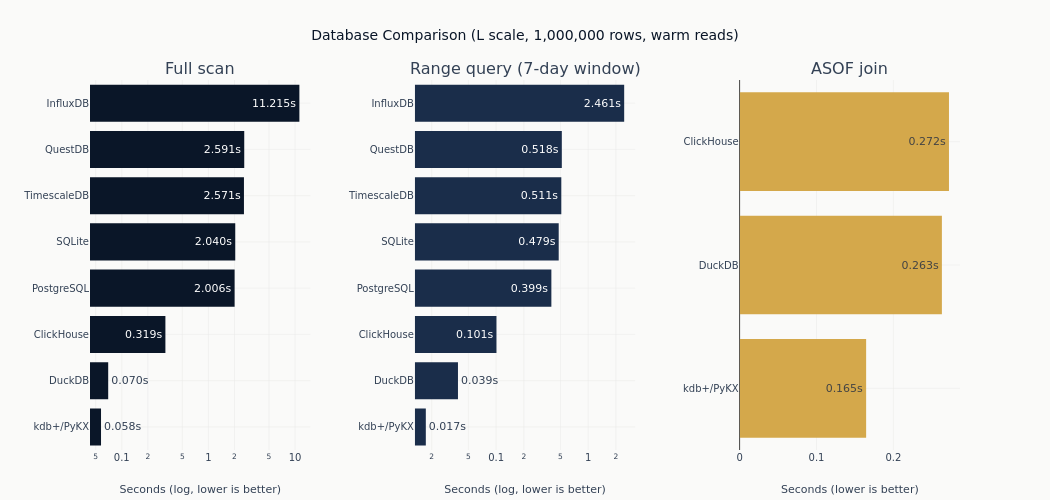

In [46]:
if results:
    # Visualization — every engine on a panel was timed under the one policy
    # stated at the top, so the bars are comparable.
    _panels = [
        ("read", "Full scan", COLORS["blue"]),
        ("range_query", f"Range query ({RANGE_QUERY_DAYS}-day window)", COLORS["slate"]),
        ("asof_join", "ASOF join", COLORS["amber"]),
    ]
    # Full scan / range query span ~30-40x across engines, so a log x-axis keeps
    # every bar legible. ASOF join runs on the three engines that support it, and
    # they sit within ~2x of each other; on a log axis a bar starts at the axis
    # floor, so a 2x spread would read as ~3x bar length. A linear axis makes bar
    # length proportional to time (honest) and preserves kdb+'s ASOF showcase.
    _LOG_OPS = {"read", "range_query"}

    fig = make_subplots(
        rows=1,
        cols=len(_panels),
        subplot_titles=[title for _, title, _ in _panels],
        horizontal_spacing=0.12,
    )

    for col, (op, _title, color) in enumerate(_panels, start=1):
        op_data = results_df.filter(pl.col("operation") == op).sort("time_s")
        if len(op_data) == 0:
            continue
        fig.add_trace(
            go.Bar(
                y=op_data["database"].to_list(),
                x=op_data["time_s"].to_list(),
                orientation="h",
                marker_color=color,
                text=[f"{t:.3f}s" for t in op_data["time_s"].to_list()],
                # "auto" keeps the longest bar's label inside the bar so it does
                # not overrun into the neighbouring panel's y-axis labels; short
                # bars still get an outside label.
                textposition="auto",
                cliponaxis=False,
            ),
            row=1,
            col=col,
        )
        if op in _LOG_OPS:
            fig.update_xaxes(
                title_text="Seconds (log, lower is better)", type="log", row=1, col=col
            )
        else:
            fig.update_xaxes(title_text="Seconds (lower is better)", type="linear", row=1, col=col)

    fig.update_layout(
        title_text=f"Database Comparison ({ACTIVE_SCALE} scale, {total_rows:,} rows, warm reads)",
        height=500,
        # Fixed width so the three panels have room to breathe in the embedded
        # PNG; the default ~700px crowds eight engines and their value labels.
        width=1050,
        showlegend=False,
        paper_bgcolor=COLORS["bg_light"],
        plot_bgcolor=COLORS["bg_light"],
        # Wider right margin so the 'X.XXXs' value labels don't crop.
        margin=dict(l=90, r=90, t=80, b=50),
    )
    fig.show()

In [47]:
if results:
    try:
        fig.write_image(
            OUTPUT_DIR / "server_database_comparison.png", width=1200, height=600, scale=2
        )
    except (RuntimeError, OSError):
        pass  # Kaleido/Chrome not available in benchmark image
    save_chart(fig, f"database_comparison_{ACTIVE_SCALE.lower()}")
    save_benchmark_results(results, "databases")

Chart saved: 02_financial_data_universe/.tmp/charts/database_comparison_l.html

📁 Results saved to: 02_financial_data_universe/output/benchmark/databases_l.csv


In [48]:
# Coverage report
print("\n### BENCHMARK COVERAGE")
tested = [k for k, v in benchmark_status.items() if v["tested"]]
expected = [k for k, v in benchmark_status.items() if v["expected"]]
print(f"Tested: {len(tested)}/{len(expected)} databases")
for db in sorted(benchmark_status.keys()):
    status = "[OK]" if benchmark_status[db]["tested"] else "[FAIL]"
    cat = benchmark_status[db]["category"]
    print(f"  {status} {db} ({cat})")

print("\n" + "=" * 70)
print("[OK] Database benchmark complete!")
print("=" * 70)


### BENCHMARK COVERAGE
Tested: 8/8 databases
  [FAIL] ArcticDB (embedded)
  [OK] ClickHouse (server)
  [OK] DuckDB (embedded)
  [OK] InfluxDB (server)
  [OK] PostgreSQL (server)
  [OK] QuestDB (server)
  [OK] SQLite (embedded)
  [OK] TimescaleDB (server)
  [OK] kdb+/PyKX (hft)

[OK] Database benchmark complete!


In [49]:
# Fastest engine per operation, read back off the results actually collected
# in THIS run. Anything not benchmarked here cannot appear.
if results:
    fastest = (
        results_df.drop_nulls("time_s")
        .sort("time_s")
        .group_by("operation", maintain_order=True)
        .first()
        .select(["operation", "database", "time_s"])
    )
    print("\nFastest engine per operation (this run):")
    print(fastest)
    print(f"\nEngines benchmarked: {', '.join(sorted(results_df['database'].unique().to_list()))}")


Fastest engine per operation (this run):
shape: (5, 3)
┌─────────────┬────────────┬──────────┐
│ operation   ┆ database   ┆ time_s   │
│ ---         ┆ ---        ┆ ---      │
│ str         ┆ str        ┆ f64      │
╞═════════════╪════════════╪══════════╡
│ range_query ┆ kdb+/PyKX  ┆ 0.01726  │
│ aggregation ┆ ClickHouse ┆ 0.022404 │
│ write       ┆ kdb+/PyKX  ┆ 0.027739 │
│ read        ┆ kdb+/PyKX  ┆ 0.057641 │
│ asof_join   ┆ kdb+/PyKX  ┆ 0.164571 │
└─────────────┴────────────┴──────────┘

Engines benchmarked: ClickHouse, DuckDB, InfluxDB, PostgreSQL, QuestDB, SQLite, TimescaleDB, kdb+/PyKX


## Key Takeaways

The engine names below are deliberately absent: which engine wins each
operation is printed by the cell above, from this run's own results, on your
hardware. What generalizes is the shape of the answer, not the ordering:

1. **Storage layout sets the scan cost.** Engines that store columns
   together and execute vectorized (DuckDB, ClickHouse) scan and aggregate a
   minute panel far faster than row-oriented engines (SQLite, PostgreSQL),
   which must touch every column of every row to answer a query about two.
2. **A range query is a different question from a scan**, and it is the one a
   backtest asks. The `RANGE_QUERY_DAYS`-day window above touches roughly a
   fifth of the panel, so engines that prune by time partition or use a
   time-ordered index separate from those that scan and filter. Ranking
   engines on full scans alone would hide that.
3. **Ingest rate and durability are one number, not two.** The write times
   here all end when the data is queryable, which is why the engines that
   acknowledge early (QuestDB ILP, InfluxDB) do not look free.
4. **The comparison is only as good as its policy.** Every number above is a
   single cold write and a warm mean read, for every engine. Warm reads
   flatter anything with a buffer pool; on a cold cache, or over a network,
   the compressed engines gain. Rerun on your own ingestion path before
   choosing.

**kdb+/PyKX** is skipped unless you supply a q binary and a license, so it is
absent from the numbers above unless you configured it. The chapter discusses
where it fits; this notebook does not claim a result it did not measure.

**Next**: See `20_storage_benchmark_file` for file-format benchmarks (Parquet, Arrow, HDF5).